#### Loading training and validation datasets

Import libraries and set directories

In [ ]:
from pathlib import Path
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter # To count the number of occurrences of each label

DATA_DIR = Path.home() / "Desktop" / "gnn_trajectory" / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

train_path = PROCESSED_DATA_DIR / "nuscenes_train_prediction_samples.pkl"
val_path = PROCESSED_DATA_DIR / "nuscenes_val_prediction_samples.pkl"

# Load dataset
with open(train_path, "rb") as f: # rb = read binary
    train_dataset = pickle.load(f)
    
with open(val_path, "rb") as f: 
    val_dataset = pickle.load(f)
    
print("Train samples: ",len(train_dataset))
print("Val samples: ",len(val_dataset))

Train samples:  25711
Val samples:  7242


A sample is only one timestep, also when saying Target we mean the ego vehicle and agent = neighbors. Below just some inital checks for one sample

In [13]:
sample = train_dataset[0]
print("Sample keys: ", sample.keys())
print("Target past shape: ", sample["target_past"].shape) 
print("Target future shape: ", sample["target_future"].shape)
print("Number of neighbors:", len(sample["neighbors_pasts"]))

Sample keys:  dict_keys(['target_past', 'target_future', 'neighbors_pasts', 'neighbors_categories', 'neighbors_distances', 'neighbor_instance_tokens', 'scene_token', 'sample_token', 'target_instance_token', 'current_ann_token', 'target_category'])
Target past shape:  (5, 2)
Target future shape:  (12, 2)
Number of neighbors: 8


#### Check neighbor density around target vehicle

Count the number of neighbors for each sample in the training and validation datasets and compute some statistics

TRAIN
Mean neighbors: 4.312123215744234
Median neighbors: 3.0
Max neighbors: 32
Zero-neighbor samples: 3349

VAL
Mean neighbors: 4.436757801712234
Median neighbors: 3.0
Max neighbors: 43
Zero-neighbor samples: 1050


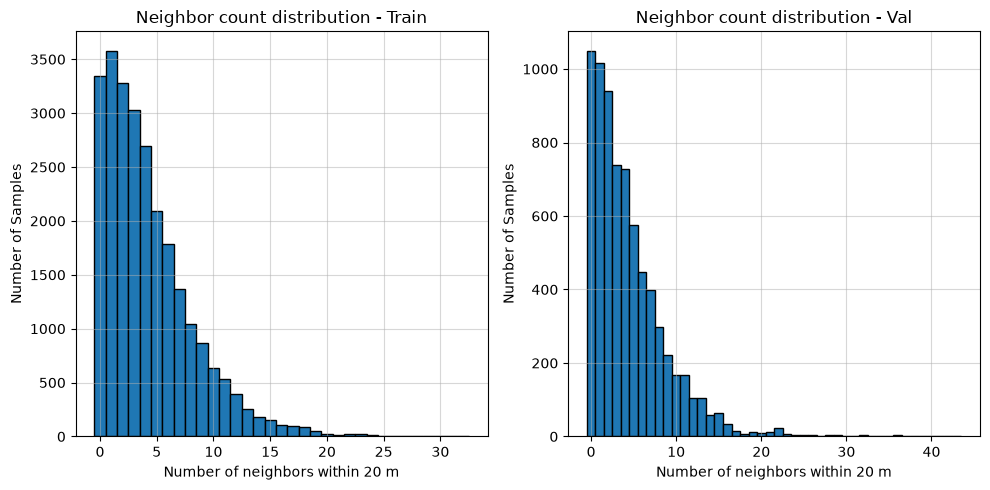

In [68]:
# Count the number of neighbors for each sample in the training and validation datasets
train_neighbor_counts = np.array([len(sample["neighbors_pasts"]) for sample in train_dataset])
val_neighbor_counts = np.array([len(sample["neighbors_pasts"]) for sample in val_dataset])

print("TRAIN")
print("Mean neighbors:", train_neighbor_counts.mean())
print("Median neighbors:", np.median(train_neighbor_counts))
print("Max neighbors:", train_neighbor_counts.max())
print("Zero-neighbor samples:", np.sum(train_neighbor_counts == 0))

print("\nVAL")
print("Mean neighbors:", val_neighbor_counts.mean())
print("Median neighbors:", np.median(val_neighbor_counts))
print("Max neighbors:", val_neighbor_counts.max())
print("Zero-neighbor samples:", np.sum(val_neighbor_counts == 0))

# Histogram of neighbor counts
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Train")
plt.hist(
    train_neighbor_counts,
    bins=np.arange(train_neighbor_counts.max() + 2) - 0.5,# to center the bins on integer values
    edgecolor='black'
)
plt.xlabel("Number of neighbors within 20 m"); plt.ylabel("Number of Samples") 
plt.title("Neighbor count distribution - Train"); plt.grid(alpha=0.5)

plt.subplot(1, 2, 2)
plt.title("Val")
plt.hist(
    val_neighbor_counts,
    bins=np.arange(val_neighbor_counts.max() + 2) - 0.5,
    edgecolor='black'
)
plt.xlabel("Number of neighbors within 20 m"); plt.ylabel("Number of Samples")
plt.title("Neighbor count distribution - Val");  plt.grid(alpha=0.5)

plt.tight_layout()
plt.show()

Define function classify the density of neighbors around target based `sparse`, `medium` and `dense` based on the number of neighbors. The thresholds are set to 1 and 4 neighbors, respectively.

In [ ]:
def density_bucket(num_neighbors):
    if num_neighbors <= 1: 
        return "sparse"
    elif num_neighbors <= 4: 
        return "medium"
    else:
        return "dense"

# Check density buckets for both datasets
train_density = Counter(density_bucket(n) for n in train_neighbor_counts)
val_density = Counter(density_bucket(n) for n in val_neighbor_counts) 

print("Train density:", train_density)
print("Validation density:", val_density)

Train density: Counter({'dense': 9783, 'medium': 8999, 'sparse': 6929})
Validation density: Counter({'dense': 2770, 'medium': 2406, 'sparse': 2066})


So both training and validation dataset have similar distribution of neighbors around the target vehicle:
- Train mean ~ 4.31 neighbors (on average) and median ~ 3.0 neighbors 
- Validation mean ~ 4.4 neighbors (on average) and median ~ 3.0 neighbors
 
So for our dataset: 
0–5 neighbors: very common
6–10 neighbors: still plenty
10+ neighbors: increasingly rare
20+ neighbors: uncommon


#### Check neighbor category distribution 

In [ ]:
# NOTE: NOT NEEDED TO RUN ANYMORE
train_neighbor_categories = Counter()
val_neighbor_categories = Counter()

# Update the counter with the categories of neighbors for this sample
for sample in train_dataset: 
    train_neighbor_categories.update(
        sample["neighbors_categories"]
    )
    
for sample in val_dataset:
    val_neighbor_categories.update(
        sample["neighbors_categories"]
    )
    
print("TRAIN")
for category, count in train_neighbor_categories.most_common():
    percentage = (count / sum(train_neighbor_categories.values())) * 100
    print(f"  {category}: {count} ({percentage:.2f}%)")

print("\nVALIDATION")
for category, count in val_neighbor_categories.most_common():
    percentage = (count / sum(val_neighbor_categories.values())) * 100
    print(f"  {category}: {count} ({percentage:.2f}%)")


In [ ]:
# NOTE: NOT NEEDED TO RUN ANYMORE
categories = [category for category, _ in train_neighbor_categories.most_common()]
counts = [train_neighbor_categories[category] for category in categories]

plt.figure(figsize=(7, 5))
plt.barh(categories, counts, edgecolor='black')

plt.xlabel("Number of neighbor appearances"); plt.ylabel("Neighbor category ")
plt.title("Neighbor category distribution — train"); 
plt.grid(axis="y", alpha=0.5)
plt.tight_layout()
plt.show()

There are a lot of unecessary categories which have very few appearances, so for feed the network as a one-hot-vector with all of these categories would be a waste of resources. Instead, we group each category into a more general one, as follows:

1. `car`

2. `truck/bus` = large vehicle

3. `bicycle/motorcycle` = two-wheeled vehicle

4. `pedestrian`

5. `other_vehicle`

In [83]:
def general_category(category):
    if category == "vehicle.car":
        return "car"
    
    elif (
        category.startswith("vehicle.truck")
        or category.startswith("vehicle.bus")
        or category.startswith("vehicle.trailer")
    ):
        return "large_vehicle"

    elif (
        category.startswith("vehicle.bicycle")
        or category.startswith("vehicle.motorcycle")
    ):
        return "two_wheeler"
    
    elif category.startswith("human.pedestrian"):
        return "pedestrian"
    
    elif category.startswith("vehicle."): 
        return "other_vehicle"
    
    else: 
        return "other"
    
# Apply function to the neighbor categories in both datasets 
train_general_categories = Counter()
val_general_categories = Counter()

for sample in train_dataset:
    for category in sample["neighbors_categories"]:
        train_general_categories[general_category(category)] += 1

for sample in val_dataset:
    for category in sample["neighbors_categories"]:
        val_general_categories[general_category(category)] += 1
        
print("TRAIN")
for category, count in train_general_categories.most_common():
    percentage = 100 * count / sum(train_general_categories.values())
    print(f"{category}: {count} ({percentage:.2f}%)")

print("\nVALIDATION")
for category, count in val_general_categories.most_common():
    percentage = 100 * count / sum(val_general_categories.values())
    print(f"{category}: {count} ({percentage:.2f}%)")
        

TRAIN
car: 66410 (59.90%)
pedestrian: 27388 (24.70%)
large_vehicle: 12081 (10.90%)
two_wheeler: 3315 (2.99%)
other_vehicle: 1675 (1.51%)

VALIDATION
car: 18373 (57.18%)
pedestrian: 8127 (25.29%)
large_vehicle: 4090 (12.73%)
two_wheeler: 1247 (3.88%)
other_vehicle: 294 (0.92%)


***NOTE:*** This counts neighbor appearances, not unique physical agents. For example, the same car can appear as a neighbor in several prediction samples, so keep that interpretation in mind.

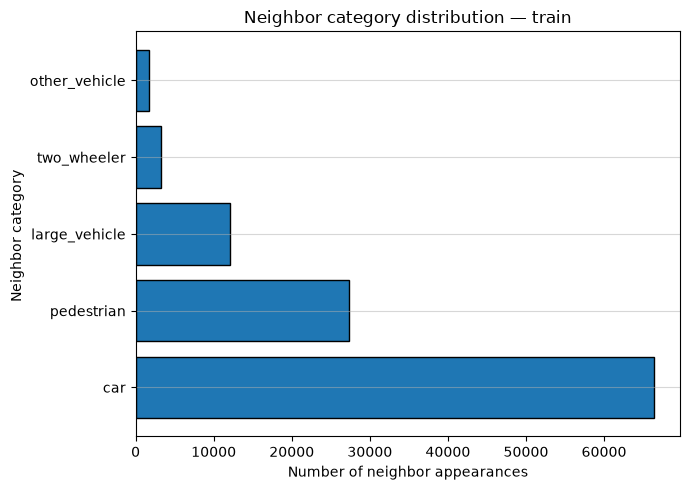

In [89]:
categories = [category for category, _ in train_general_categories.most_common()]
counts = [train_general_categories[category] for category in categories]

plt.figure(figsize=(7, 5))
plt.barh(categories, counts, edgecolor='black') 

plt.xlabel("Number of neighbor appearances"); plt.ylabel("Neighbor category ")
plt.title("Neighbor category distribution — train"); plt.grid(axis="y", alpha=0.5)

plt.tight_layout()
plt.show()